# 04 - Real-world case study: the Facebook social network

Every other notebook in this project works with **synthetic** networks (ring
lattice, Erdős–Rényi, Watts–Strogatz) that we build ourselves. Here we turn the
problem around: we take a **real network** and ask whether the theory actually
describes it.

Two questions drive this notebook:

1. **Is the Facebook friendship network really *small-world*** — high
   clustering *and* short paths — or does it only look that way?
2. If it is, **which Watts–Strogatz model reproduces it**? That is, at what
   rewiring probability $\beta$ would a regular ring acquire the same $L$ and
   $C$ as Facebook?

The intuition: a social network should have tightly-knit groups (your friends
know each other → high $C$) yet still connect distant people in few hops (the
*six degrees of separation* → small $L$). That is exactly the small-world
regime, so Facebook is the perfect test case.

In [1]:
%load_ext autoreload
%autoreload 2

import json
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from src.smallworld.real_network import (
    load_facebook,
    smallworldness_sigma,
    fit_ws,
    plot_fitting_curve,
)
from src.smallworld.networks import build_ws

## 1. Loading the real network

The dataset is **Facebook Social Circles** (McAuley & Leskovec, NIPS 2012),
published by [SNAP](https://snap.stanford.edu/data/ego-Facebook.html): an
anonymised set of real ego-network friendships, undirected and connected.

It is small (218 KB) and static, so it **ships with the repo** in `data/` —
no download needed. `load_facebook(path)` reads the edge list and returns the
**largest connected component**, so it plugs straight into everything we built
for synthetic graphs. (Called with no argument it would instead fetch the file
from SNAP the first time and cache it.)

In [2]:
# the dataset ships with the repo (data/), so this never hits the network
G_fb = load_facebook(ROOT / "data" / "facebook_combined.txt.gz")

N = G_fb.number_of_nodes()
M = G_fb.number_of_edges()
avg_deg = 2 * M / N

print("Facebook Social Circles (SNAP)")
print(f"  nodes     : {N}")
print(f"  edges     : {M}")
print(f"  <degree>  : {avg_deg:.2f}")
print(f"  connected : {nx.is_connected(G_fb)}")

Facebook Social Circles (SNAP)
  nodes     : 4039
  edges     : 88234
  <degree>  : 43.69
  connected : True


## 2. The two structural metrics

We need the same two numbers as for the synthetic networks:

* **$C$** — clustering coefficient. Cheap: NetworkX computes it directly.
* **$L$** — average path length. **Not** cheap: exact all-pairs shortest paths
  on 4 039 nodes is $O(N\,(N+M))$ and far too slow.

So we *estimate* $L$ by running BFS from a random **sample** of source nodes
and averaging the distances. For a large connected graph this is accurate and
orders of magnitude faster. Writing it out makes the trick explicit (it is the
same idea as the `_sample_apl` helper inside `real_network.py`):

In [3]:
def sample_apl(G, n_samples=500, seed=42):
    """Estimate L by BFS from a random sample of source nodes."""
    rng = np.random.default_rng(seed)
    sources = rng.choice(list(G.nodes()),
                         size=min(n_samples, G.number_of_nodes()),
                         replace=False)
    total, count = 0.0, 0
    for s in sources:
        lengths = nx.single_source_shortest_path_length(G, int(s))
        total += sum(d for t, d in lengths.items() if t != s)
        count += len(lengths) - 1          # exclude the source itself
    return total / count


C_real = nx.average_clustering(G_fb)
L_real = sample_apl(G_fb, n_samples=500, seed=42)

print(f"C (clustering)      : {C_real:.4f}")
print(f"L (avg path length) : {L_real:.4f}")

C (clustering)      : 0.6055
L (avg path length) : 3.7064


A clustering of ~0.61 is **very** high (61% of a node's neighbours are
themselves connected), while $L \approx 3.7$ means any two of the 4 039 people
are, on average, fewer than four hops apart. That already smells small-world —
but high $C$ and low $L$ on their own are not proof. We need a reference.

## 3. Is Facebook really small-world?

The **smallworldness coefficient** $\sigma$ compares the network to an
equivalent *random* graph (same $N$, same edge probability
$p = 2|E| / (N(N-1))$):

$$
\sigma = \frac{C_{\text{real}} / C_{\text{rand}}}
              {L_{\text{real}} / L_{\text{rand}}}
$$

A network is small-world when it has **much more clustering** than random
($C_{\text{real}} \gg C_{\text{rand}}$, big numerator) while keeping paths
**almost as short** as random ($L_{\text{real}} \approx L_{\text{rand}}$,
denominator near 1). So $\sigma > 1$ signals small-world behaviour, and the
larger the better.

`smallworldness_sigma` builds several reference ER graphs and samples $L$ on
each, which takes a few minutes. To keep the notebook instant we reuse the
cached result in `data/facebook_cache.json` (the same one the documentation
build produces); the `else` branch shows exactly how it would be recomputed.

In [4]:
FB_CACHE = ROOT / "data" / "facebook_cache.json"

if FB_CACHE.exists():
    with open(FB_CACHE, encoding="utf-8") as fh:
        cached = json.load(fh)
    sigma_result = cached["sigma_result"]
    fit_result   = cached["fit_result"]
    print(f"Loaded cached results from {FB_CACHE.relative_to(ROOT)}")
else:
    # Slow path (~5-10 min): builds reference ER graphs and samples L on each.
    sigma_result = smallworldness_sigma(G_fb, n_random=10, n_apl_samples=100)
    fit_result   = fit_ws(G_fb, beta_values=list(np.logspace(-3, 0, 15)),
                          n_reps=3, n_apl_samples=100, verbose=True)

Loaded cached results from data\facebook_cache.json


In [5]:
ratio_C = sigma_result["C_real"] / sigma_result["C_rand"]
ratio_L = sigma_result["L_real"] / sigma_result["L_rand"]

print(f"C_real / C_rand = {sigma_result['C_real']:.4f} / {sigma_result['C_rand']:.4f} = {ratio_C:6.1f}")
print(f"L_real / L_rand = {sigma_result['L_real']:.4f} / {sigma_result['L_rand']:.4f} = {ratio_L:6.2f}")
print(f"\nsigma = ({ratio_C:.1f}) / ({ratio_L:.2f}) = {sigma_result['sigma']:.2f}")

C_real / C_rand = 0.6055 / 0.0108 =   55.9
L_real / L_rand = 3.7279 / 2.6027 =   1.43

sigma = (55.9) / (1.43) = 39.02


**Reading.** $\sigma \approx 39$ — decisively small-world. The breakdown tells
the whole story: Facebook has about **56× more clustering** than a random graph
of the same size, while its paths are only about **40% longer**. Strong local
structure, almost no penalty in global distance — the small-world signature.

## 4. Which Watts–Strogatz reproduces it?

Now the reverse-engineering. `fit_ws` searches for the
$\text{WS}(N, k, \beta)$ model whose $(L, C)$ best matches Facebook:

1. **Derive** $N$ and $k$ from the real graph ($k$ = mean degree, rounded to
   the nearest even integer).
2. Build a **ring** baseline ($\beta\to0$) and an **ER** baseline
   ($\beta\to1$) to fix the range of each metric.
3. **Normalise** $L$ and $C$ to $[0, 1]$ using those two extremes, so the two
   metrics live on a common scale.
4. **Sweep** $\beta$, averaging $(L, C)$ over a few WS realisations per value.
5. Return $\beta^\*$ = the $\beta$ whose normalised point is **closest**
   (Euclidean distance) to the real-network point.

The result was computed alongside $\sigma$ in the cached `fit_result`.

In [6]:
print(f"Derived parameters :  N = {fit_result['N']},  k = {fit_result['k']}")
print(f"Optimal rewiring   :  beta* = {fit_result['beta_optimal']:.4f}")
print()
print(f"  Facebook (real)  :  L = {fit_result['L_real']:.3f},  C = {fit_result['C_real']:.3f}")
print(f"  WS at beta*      :  L = {fit_result['L_ws_fitted']:.3f},  C = {fit_result['C_ws_fitted']:.3f}")
print(f"  fit distance     :  {fit_result['distance']:.4f}")

Derived parameters :  N = 4039,  k = 44
Optimal rewiring   :  beta* = 0.0518

  Facebook (real)  :  L = 3.728,  C = 0.606
  WS at beta*      :  L = 3.200,  C = 0.624
  fit distance     :  0.0283


**Reading.** $\beta^* \approx 0.05$: rewiring only **~5% of the edges** of a
regular ring already recreates Facebook's $L$ and $C$. That value sits squarely
inside the **small-world window** $\beta \in [10^{-2}, 10^{-1}]$ found in
notebook 02 — a real social network lives exactly in the regime the
Watts–Strogatz model flags as interesting.

## 5. Visualising the fit

`plot_fitting_curve` draws the whole argument in two panels:

* **Left** — the WS $\beta$-curve in normalised $(L, C)$ space, running from the
  ring ($\beta\to0$, top-right) to random ($\beta\to1$, bottom-left). The red
  diamond is Facebook and the green star marks $\beta^*$, the point on the
  curve closest to it.
* **Right** — the $\sigma$ breakdown: a huge $C/C_{\text{rand}}$ bar next to a
  near-1 $L/L_{\text{rand}}$ bar, whose ratio is $\sigma$.

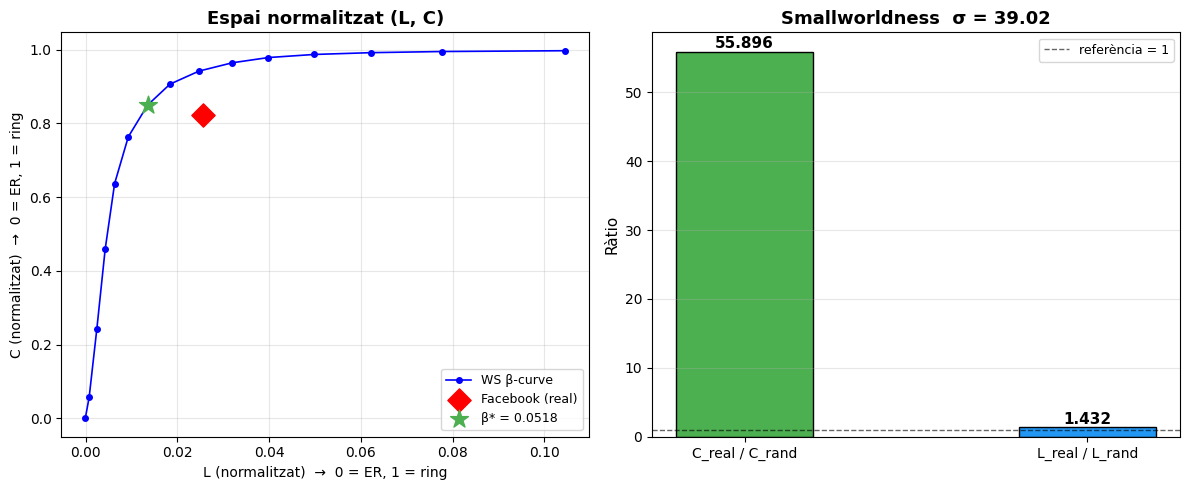

In [7]:
fig, axes = plot_fitting_curve(
    fit_result, sigma_result, save_path=FIGURES / "05_facebook_fitting.png"
)
plt.show()

## 6. What Watts–Strogatz misses: the degree distribution

The fit is good, but $\beta^*$ only matches $L$ and $C$. It hides a real
limitation of the model. In Watts–Strogatz **every node starts with degree
$k$**; rewiring shuffles *which* edges exist but barely changes *how many* each
node has, so degrees stay tightly bunched around $k$.

Real social networks are not like that: a few **hubs** (celebrities,
super-connectors) have enormous degree while most users have few friends. This
heavy-tailed, **scale-free** shape ($P(k)\sim k^{-\gamma}$) is something WS
cannot produce. Let's compare the two degree distributions directly:

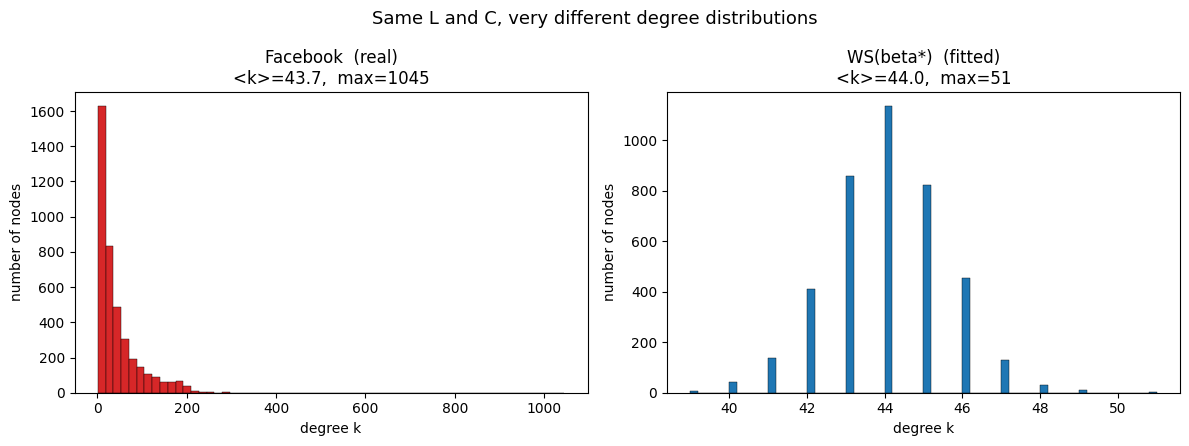

In [8]:
deg_fb = [d for _, d in G_fb.degree()]

G_ws = build_ws(fit_result["N"], fit_result["k"],
                fit_result["beta_optimal"], seed=0)
deg_ws = [d for _, d in G_ws.degree()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.hist(deg_fb, bins=60, color="#d62728", edgecolor="black", linewidth=0.3)
ax1.set_title(f"Facebook  (real)\n<k>={np.mean(deg_fb):.1f},  max={max(deg_fb)}")
ax1.set_xlabel("degree k"); ax1.set_ylabel("number of nodes")

ax2.hist(deg_ws, bins=60, color="#1f77b4", edgecolor="black", linewidth=0.3)
ax2.set_title(f"WS(beta*)  (fitted)\n<k>={np.mean(deg_ws):.1f},  max={max(deg_ws)}")
ax2.set_xlabel("degree k"); ax2.set_ylabel("number of nodes")

fig.suptitle("Same L and C, very different degree distributions", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES / "05_degree_distributions.png", dpi=150)
plt.show()

**Reading.** The WS histogram (right) is a narrow bump centred on $k$ — almost
every node has a similar number of friends. Facebook (left) has a long right
tail reaching into the hundreds: hubs that WS simply cannot create. Reproducing
*that* needs a growth mechanism — **preferential attachment** (Barabási–Albert,
1999), where new nodes attach preferentially to already-popular ones. WS
explains the *path/clustering trade-off*; it does not explain *hubs*.

## 7. Conclusions

- **Facebook is demonstrably small-world**, not just suspected: $\sigma \approx 39$,
  driven by ~56× the clustering of a random graph at almost no cost in path
  length.
- **It matches Watts–Strogatz with $\beta^* \approx 0.05$** — about 5% rewiring —
  which lands inside the small-world window $[10^{-2}, 10^{-1}]$ from notebook 02.
  The model validates outside the lab.
- **But WS is not the whole story.** It reproduces $L$ and $C$ while assuming all
  nodes are roughly equal. Facebook's heavy-tailed (scale-free) degree
  distribution — its hubs — needs a different mechanism (preferential
  attachment). All models are abstractions: WS tells us something true (a little
  disorder unlocks short paths) without telling us everything.